# CMPE 401 — Project 1
## Design, Optimization, and Comparative Evaluation of Modern YOLO Models
### Dataset: VisDrone | Primary Model: YOLOv11n

**Parts covered:**
- Part I: Baseline Model (YOLOv11n)
- Part II: Loss Curve & Fitting Analysis
- Part III: Structured Experimental Design
- Part IV: Iterative Model Improvement
- Part V: Multi-Version YOLO Comparison

## 0. Setup

In [3]:
!nvidia-smi
!pip install ultralytics -q

import os
import yaml
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DRIVE = '/content/drive/MyDrive'
RESULTS_DIR = f'{DRIVE}/yolo_results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete!')

Thu Apr 16 06:32:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Extract & Convert VisDrone Dataset

In [4]:
import zipfile, os

VISDRONE_RAW  = '/content/drive/MyDrive'
VISDRONE_YOLO = '/content/drive/MyDrive/visdrone_yolo'

splits = [
    ('VisDrone2019-DET-train.zip', 'VisDrone2019-DET-train'),
    ('VisDrone2019-DET-val.zip',   'VisDrone2019-DET-val'),
]

for zipname, folder in splits:
    zip_path = f'{VISDRONE_RAW}/{zipname}'
    out_path = f'{VISDRONE_RAW}/{folder}'
    if not os.path.exists(out_path):
        print(f'Extracting {zipname}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(VISDRONE_RAW)
        print('Done!')
    else:
        print(f'Already extracted: {folder}')

print('All done!')

Already extracted: VisDrone2019-DET-train
Already extracted: VisDrone2019-DET-val
All done!


In [5]:
import cv2
from tqdm import tqdm

# VisDrone category mapping
VISDRONE_CLASSES = {1:0, 2:1, 3:2, 4:3, 5:4, 6:5, 7:6, 8:7, 9:8, 10:9}
CLASS_NAMES = ['pedestrian','people','bicycle','car','van','truck','tricycle','awning-tricycle','bus','motor']

def convert_visdrone_to_yolo(src_img_dir, src_ann_dir, dst_img_dir, dst_lbl_dir):
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)
    ann_files = list(Path(src_ann_dir).glob('*.txt'))
    skipped = 0
    for ann_path in tqdm(ann_files, desc=f'Converting'):
        img_name = ann_path.stem + '.jpg'
        img_path = Path(src_img_dir) / img_name
        if not img_path.exists():
            skipped += 1
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            skipped += 1
            continue
        H, W = img.shape[:2]
        yolo_lines = []
        with open(ann_path) as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 6:
                    continue
                x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                cat = int(parts[5])
                if cat not in VISDRONE_CLASSES or w == 0 or h == 0:
                    continue
                cls = VISDRONE_CLASSES[cat]
                xc = max(0, min(1, (x + w/2) / W))
                yc = max(0, min(1, (y + h/2) / H))
                wn = max(0, min(1, w / W))
                hn = max(0, min(1, h / H))
                yolo_lines.append(f'{cls} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}')
        shutil.copy(img_path, Path(dst_img_dir) / img_name)
        with open(Path(dst_lbl_dir) / (ann_path.stem + '.txt'), 'w') as f:
            f.write('\n'.join(yolo_lines))
    print(f'Done. Skipped {skipped} files.')

# Only convert if not already done
if not os.path.exists(f'{VISDRONE_YOLO}/images/train'):
    print('Converting train set...')
    convert_visdrone_to_yolo(
        f'{VISDRONE_RAW}/VisDrone2019-DET-train/images',
        f'{VISDRONE_RAW}/VisDrone2019-DET-train/annotations',
        f'{VISDRONE_YOLO}/images/train',
        f'{VISDRONE_YOLO}/labels/train'
    )
    print('Converting val set...')
    convert_visdrone_to_yolo(
        f'{VISDRONE_RAW}/VisDrone2019-DET-val/images',
        f'{VISDRONE_RAW}/VisDrone2019-DET-val/annotations',
        f'{VISDRONE_YOLO}/images/val',
        f'{VISDRONE_YOLO}/labels/val'
    )
else:
    print('Dataset already converted!')

# Write YAML
yaml_path = f'{VISDRONE_YOLO}/visdrone.yaml'
dataset_yaml = {'path': VISDRONE_YOLO, 'train': 'images/train', 'val': 'images/val',
                'nc': 10, 'names': CLASS_NAMES}
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f)
print(f'YAML saved: {yaml_path}')

Dataset already converted!
YAML saved: /content/drive/MyDrive/visdrone_yolo/visdrone.yaml


---
## PART I — Baseline Model (YOLOv11n)

In [6]:
def train_yolo(model_name, run_name, epochs=50, imgsz=640, batch=16, lr=0.01):
    model = YOLO(model_name)
    start = time.time()
    results = model.train(
        data=yaml_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        lr0=lr,
        optimizer='SGD',
        project=RESULTS_DIR,
        name=run_name,
        exist_ok=True,
        patience=15,
        save=True,
        plots=True,
        verbose=False
    )
    elapsed = time.time() - start
    val = model.val(data=yaml_path, split='val', verbose=False)
    metrics = {
        'model': run_name,
        'mAP50':      round(float(val.box.map50), 4),
        'mAP50-95':   round(float(val.box.map),   4),
        'precision':  round(float(val.box.mp),    4),
        'recall':     round(float(val.box.mr),    4),
        'train_time_hrs': round(elapsed / 3600, 2)
    }
    print(f"\n{'='*50}")
    print(f"Results for {run_name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
    return metrics, model

# Train baseline
print('Training YOLOv11n baseline...')
baseline_metrics, baseline_model = train_yolo('yolo11n.pt', 'baseline_yolo11n')
print('Baseline training complete!')

Training YOLOv11n baseline...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolo11n, nbs=64, nms=False, op

---
## PART II — Loss Curve & Fitting Analysis

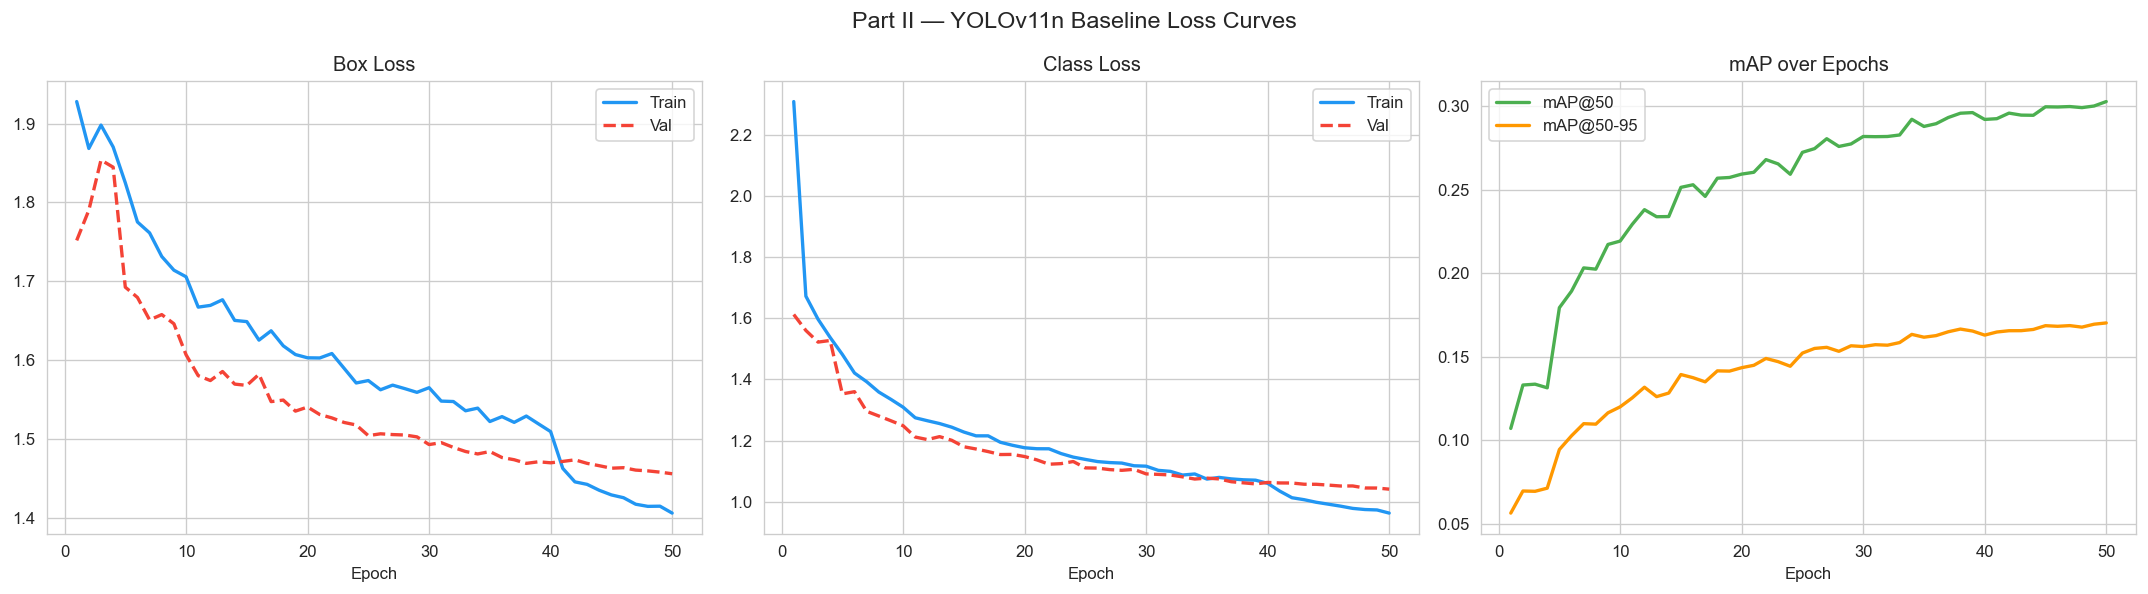


Fitting Analysis (last 5 epochs avg):
  Train Box Loss: 1.4153
  Val Box Loss:   1.4592
  Gap:            0.0439
  Diagnosis: GOOD FIT


In [7]:
def plot_loss_curves(run_name, title='Loss Curves', save_path=None):
    csv_path = f'{RESULTS_DIR}/{run_name}/results.csv'
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].plot(df['epoch'], df['train/box_loss'], label='Train', color='#2196F3', linewidth=2)
    axes[0].plot(df['epoch'], df['val/box_loss'],   label='Val',   color='#F44336', linewidth=2, linestyle='--')
    axes[0].set_title('Box Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='#2196F3', linewidth=2)
    axes[1].plot(df['epoch'], df['val/cls_loss'],   label='Val',   color='#F44336', linewidth=2, linestyle='--')
    axes[1].set_title('Class Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    axes[2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP@50',    color='#4CAF50', linewidth=2)
    axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#FF9800', linewidth=2)
    axes[2].set_title('mAP over Epochs'); axes[2].set_xlabel('Epoch'); axes[2].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    # Fitting analysis
    final_train = df['train/box_loss'].iloc[-5:].mean()
    final_val   = df['val/box_loss'].iloc[-5:].mean()
    gap = final_val - final_train
    print(f'\nFitting Analysis (last 5 epochs avg):')
    print(f'  Train Box Loss: {final_train:.4f}')
    print(f'  Val Box Loss:   {final_val:.4f}')
    print(f'  Gap:            {gap:.4f}')
    if gap > 0.3:
        print('  Diagnosis: OVERFITTING')
    elif final_train > 1.5:
        print('  Diagnosis: UNDERFITTING')
    else:
        print('  Diagnosis: GOOD FIT')
    return df

df_baseline = plot_loss_curves(
    'baseline_yolo11n',
    title='Part II — YOLOv11n Baseline Loss Curves',
    save_path=f'{RESULTS_DIR}/baseline_loss_curves.png'
)

---
## PART III — Structured Experimental Design
### Experiment: Model Size Comparison (n vs s vs m)

In [8]:
def train_yolo(model_name, run_name, epochs=50, imgsz=640, batch=16, lr=0.01):
    model = YOLO(model_name)
    start = time.time()
    results = model.train(
        data=yaml_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        lr0=lr,
        optimizer='SGD',
        project=RESULTS_DIR,
        name=run_name,
        exist_ok=True,
        patience=15,
        save=True,
        plots=True,
        verbose=False
    )
    elapsed = time.time() - start
    val = model.val(data=yaml_path, split='val', verbose=False)
    metrics = {
        'model': run_name,
        'mAP50':      round(float(val.box.map50), 4),
        'mAP50-95':   round(float(val.box.map),   4),
        'precision':  round(float(val.box.mp),    4),
        'recall':     round(float(val.box.mr),    4),
        'train_time_hrs': round(elapsed / 3600, 2)
    }
    print(f"\n{'='*50}")
    print(f"Results for {run_name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
    return metrics, model

# Experiment: model size
# Variable: model size (n / s / m)
# All other settings held constant
print('Training YOLOv11s...')
exp1_metrics, _ = train_yolo('yolo11s.pt', 'exp_yolo11s')
print('Done!')

Training YOLOv11s...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_yolo11s, nbs=64, nms=False, opset=None, opti

In [9]:
print('Training YOLOv11m...')
exp2_metrics, _ = train_yolo('yolo11m.pt', 'exp_yolo11m')
print('Done!')

Training YOLOv11m...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_yolo11m, nbs=64, nms=False, opset=None, opti

In [10]:
# Part III results table
exp_results = pd.DataFrame([baseline_metrics, exp1_metrics, exp2_metrics])
exp_results['model'] = ['YOLOv11n (baseline)', 'YOLOv11s', 'YOLOv11m']
print('\n===== PART III — Model Size Experiment =====')
print(exp_results.to_string(index=False))
exp_results.to_csv(f'{RESULTS_DIR}/part3_experiment.csv', index=False)


===== PART III — Model Size Experiment =====
              model  mAP50  mAP50-95  precision  recall  train_time_hrs
YOLOv11n (baseline) 0.3027    0.1710     0.4361  0.3263            1.16
           YOLOv11s 0.3802    0.2209     0.5272  0.3807            0.78
           YOLOv11m 0.4498    0.2703     0.5811  0.4464            0.96


---
## PART IV — Iterative Model Improvement
### Improvement: Higher Resolution (640 → 1280)

In [11]:
# Baseline -> Experimental Settings -> Controlled Modification -> Evaluation
# Modification: increase image resolution from 640 to 1280
# Motivation: VisDrone has small objects -- higher resolution helps detect them
# All other settings identical to baseline
print('Training improvement: YOLOv11n at imgsz=1280...')
imp_metrics, _ = train_yolo('yolo11n.pt', 'imp_yolo11n_1280', imgsz=1280, batch=8)
print('Done!')

Training improvement: YOLOv11n at imgsz=1280...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=imp_yolo11n_1280, nbs

In [12]:
# Part IV comparison table
imp_results = pd.DataFrame([
    {**baseline_metrics, 'model': 'Baseline (640)', 'imgsz': 640},
    {**imp_metrics,      'model': 'Improved (1280)', 'imgsz': 1280},
])
print('\n===== PART IV — Improvement Results =====')
print(imp_results.to_string(index=False))
imp_results.to_csv(f'{RESULTS_DIR}/part4_improvement.csv', index=False)

# Analysis
delta_map = imp_metrics['mAP50'] - baseline_metrics['mAP50']
print(f'\nmAP50 change: {delta_map:+.4f}')
if delta_map > 0:
    print('Conclusion: Higher resolution improves small object detection on VisDrone.')
else:
    print('Conclusion: Resolution increase did not improve mAP -- possible overfitting or insufficient epochs.')


===== PART IV — Improvement Results =====
          model  mAP50  mAP50-95  precision  recall  train_time_hrs  imgsz
 Baseline (640) 0.3027    0.1710     0.4361  0.3263            1.16    640
Improved (1280) 0.4600    0.2797     0.5651  0.4571            1.69   1280

mAP50 change: +0.1573
Conclusion: Higher resolution improves small object detection on VisDrone.


---
## PART V — Multi-Version YOLO Comparison
Comparing YOLOv11 with YOLOv5, YOLOv8, YOLOv9, YOLOv10

In [13]:
print('Training YOLOv8n...')
v8_metrics, _ = train_yolo('yolov8n.pt', 'compare_yolov8n')
print('Done!')

Training YOLOv8n...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=compare_yolov8n, nbs=64, nms=False, opset=None, o

In [14]:
print('Training YOLOv9c...')
v9_metrics, _ = train_yolo('yolov9c.pt', 'compare_yolov9c')
print('Done!')

Training YOLOv9c...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=compare_yolov9c, nbs=64, nms=False, opset=None, o

In [15]:
print('Training YOLOv10n...')
v10_metrics, _ = train_yolo('yolov10n.pt', 'compare_yolov10n')
print('Done!')

Training YOLOv10n...
New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.

In [16]:
print('Training YOLOv5nu...')
v5_metrics, _ = train_yolo('yolov5nu.pt', 'compare_yolov5nu')
print('Done!')

Training YOLOv5nu...
New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/visdrone_yolo/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.

In [17]:
# Final comparison table
all_metrics = [baseline_metrics, v8_metrics, v9_metrics, v10_metrics, v5_metrics]
labels = ['YOLOv11n', 'YOLOv8n', 'YOLOv9c', 'YOLOv10n', 'YOLOv5nu']
for m, l in zip(all_metrics, labels):
    m['model'] = l

comparison_df = pd.DataFrame(all_metrics)
print('\n===== PART V — Multi-Version YOLO Comparison =====')
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f'{RESULTS_DIR}/part5_comparison.csv', index=False)


===== PART V — Multi-Version YOLO Comparison =====
   model  mAP50  mAP50-95  precision  recall  train_time_hrs
YOLOv11n 0.3027    0.1710     0.4361  0.3263            1.16
 YOLOv8n 0.3087    0.1734     0.4328  0.3327            0.67
 YOLOv9c 0.4445    0.2649     0.5697  0.4459            1.25
YOLOv10n 0.2971    0.1659     0.4244  0.3269            0.96
YOLOv5nu 0.2866    0.1607     0.4254  0.3099            0.71


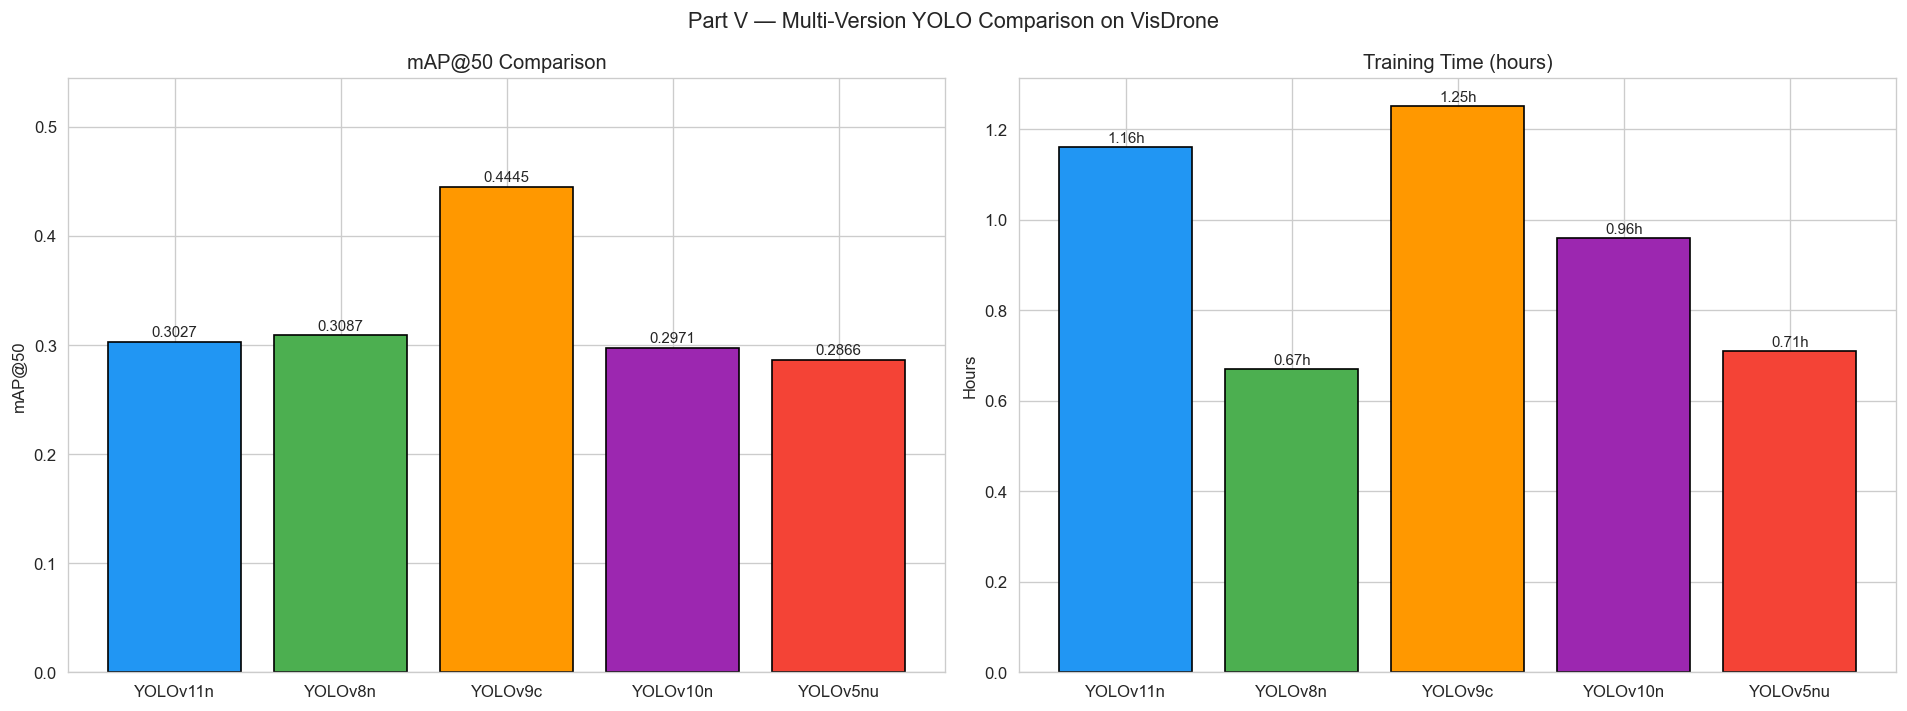

Saved!


In [18]:
# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

bars = axes[0].bar(comparison_df['model'], comparison_df['mAP50'], color=colors, edgecolor='black')
axes[0].set_title('mAP@50 Comparison', fontweight='bold')
axes[0].set_ylabel('mAP@50')
axes[0].set_ylim(0, max(comparison_df['mAP50']) + 0.1)
for bar, val in zip(bars, comparison_df['mAP50']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(comparison_df['model'], comparison_df['train_time_hrs'], color=colors, edgecolor='black')
axes[1].set_title('Training Time (hours)', fontweight='bold')
axes[1].set_ylabel('Hours')
for bar, val in zip(bars2, comparison_df['train_time_hrs']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val}h', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Part V — Multi-Version YOLO Comparison on VisDrone', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/part5_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved!')

In [19]:
print('\n===== ALL RESULTS SUMMARY =====')
print(f'Results saved to: {RESULTS_DIR}')
print('Files:')
for f in os.listdir(RESULTS_DIR):
    print(f'  {f}')


===== ALL RESULTS SUMMARY =====
Results saved to: /content/drive/MyDrive/yolo_results
Files:
  baseline_yolo11n
  exp_yolo11s
  exp_yolo11m
  imp_yolo11n_1280
  part3_experiment.csv
  compare_yolov8n
  compare_yolov9c
  compare_yolov10n
  compare_yolov5nu
  part5_comparison.csv
  exp_yolo11m_final
  test_challenge_predictions
  baseline_loss_curves.png
  part4_improvement.csv
  part5_comparison.png
